The purpose of this notebook is to test out the many flavors of noise integration. Because I intend to integrate 2 noise processes, the discretation gets really hairy.
The general form of the equations are:
$$
\begin{align}
\dot{x} &= -\frac{1}{\tau_x} x + \eta \\
\dot{\eta} &= -\frac{1}{\tau_{\eta}} \eta + \sigma_f \dot{W}.
\end{align}
$$
$x$ and $\eta$ are noise processes governed by their characteristic timescales ($\tau_x$ and $\tau_{\eta}$). $\eta$ is driven by a white noise process $\dot{W}$ with variance $\sigma_f^2$ such that the final variance of $x$ is $\sigma_x^2$.

Here, I demonstrate 3 ways to integrate this system:
1. "Naive" AR(1) integration of an AR(1).
2. Euler-Maruyama 2D
3. Continuous-to-discrete simulation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg, signal

# What are differences between the three integration schemes?

In [2]:
## tunable parameters of noise
tau_x = 10.0  # e‐folding time of x [years]
tau_eta = 1.0  # e‐folding time of η [years]
variance_x = 200.0  # desired variance of x [ppb^2]
dt = 1 / 12  # time step [years]
years = 1000  # length of each simulation [years]
n_ens = 1  # number of ensemble members
N = int(years / dt)

## Closed-form solution of variance
Rewrite equations (1) and (2) in matrix form:
$$
\begin{equation}
d{\bf s} = {\bf A s}\, dt + {\bf B}\, dW, 
\quad {\bf s}=\begin{pmatrix}x\\ \eta\end{pmatrix} \tag{3}
\end{equation}
$$
in which
$$
\begin{equation}
{\bf A} = \begin{pmatrix}-\frac{1}{\tau_x} & 1 \\ 0 & -\frac{1}{\tau_{\eta}}\end{pmatrix}, \quad
{\bf B} = \begin{pmatrix}0 \\ \sigma_f\end{pmatrix}. \tag{4}
\end{equation}
$$

Given that the system is stationary, the Lyapunov equation for the covariance matrix ${\bf \Sigma}$ is given by
$$
\begin{equation}
\frac{d{\bf \Sigma}}{dt} = {\bf A \Sigma + \Sigma A^T + B B^T} = 0. \tag{5}
\end{equation}
$$
The terms of the covariance matrix are given by
$$
\begin{equation}
{\bf \Sigma} = \begin{pmatrix}\sigma_x^2 & \sigma_{x\eta} \\ \sigma_{x\eta} & \sigma_{\eta}^2\end{pmatrix}. \tag{6}
\end{equation}
$$

Solving the Lyapunov equation (nitty gritty details in the next cell) gives the following closed-form solution for the variances of $x$, $\eta$, their covariance, and $\sigma_f$:
$$
\begin{align}
\sigma_x^2 &= \frac{\sigma_f^2 \tau_x^2 \tau_{\eta}^2}{2(\tau_x + \tau_{\eta})} = \frac{\sigma_{\eta}^2 \tau_x^2 \tau_{\eta}}{\tau_x + \tau_{\eta}} \tag{7} \\
\sigma_{\eta}^2 &= \frac{\sigma_f^2 \tau_{\eta}^2}{2} \tag{8} \\
\sigma_{x\eta} &= \frac{\sigma_n^2 \tau_x \tau_{\eta}}{\tau_x + \tau_{\eta}}. \tag{9}
\end{align}
$$

### Nitty gritty details of deriving the closed-form solution
First, use the 2, 2 element of the Lyapunov equation (5) to get
$$
\begin{equation}
\frac{d\Sigma}{dt}_{2,2} = ({\bf A \Sigma})_{2,2} + ({\bf \Sigma A^\intercal})_{2,2} + ({\bf B B^\intercal})_{2,2} =
-\frac{1}{\tau_{\eta}} \sigma_{\eta}^2 - \frac{1}{\tau_{\eta}} \sigma_{\eta}^2 + \sigma_f^2 = 0. \tag{10} 
\end{equation}
$$
Rearranging gives
$$
\begin{equation}
\sigma_{\eta}^2 = \frac{\sigma_f^2 \tau_{\eta}}{2}. \tag{11}
\end{equation}
$$


Second, in the same style of derivation for $\sigma_{\eta}^2$, use the 1, 1 element of the Lyapunov equation (5) to get
$$
\begin{equation}
\frac{d\Sigma}{dt}_{1,1} = \left(-\frac{1}{\tau_x} \sigma_x^2 + \sigma_{x\eta} \right) + \left(-\frac{1}{\tau_x} \sigma_x^2 + \sigma_{x\eta} \right) = 0. \tag{12}
\end{equation}
$$
Rearranging gives
$$
\begin{equation}
\sigma_x^2 = \sigma_{x\eta} \tau_x. \tag{13}
\end{equation}
$$

Third, derive the covariance $\sigma_{x\eta}$ using the 1, 2 element of the Lyapunov equation (5):
$$
\begin{equation}
\frac{d\Sigma}{dt}_{1,2} = \left(-\frac{1}{\tau_x} \sigma_{x\eta} + \sigma_\eta^2 \right) -\frac{1}{\tau_\eta} \sigma_{x\eta} = 0. \tag{14}
\end{equation}
$$
Rearranging gives
$$
\begin{equation}
\sigma_{x\eta} = \frac{\sigma_\eta^2 \tau_x \tau_{\eta}}{\tau_x + \tau_{\eta}}. \tag{15}
\end{equation}
$$

You can derive the closed-form solutions for $\sigma_x^2$ and $\sigma_{\eta}^2$ by rearranging equations (11), (13), and (15).

In [3]:
## closed-form solution to the variance of eta and forcing
def calculate_variance_eta(variance_x, tau_x, tau_eta):
    """
    Calculate the variance of eta based on the variance of x and the e-folding times.
    """
    return variance_x * (tau_x + tau_eta) / tau_x**2 / tau_eta


def calculate_variance_forcing(variance_x, tau_x, tau_eta):
    """
    Calculate the variance of the forcing based on the variance of x and the e-folding times.
    """
    return variance_x * 2 * (tau_x + tau_eta) / tau_x**2 / tau_eta**2


print(
    f"Variance of eta: {calculate_variance_eta(variance_x, tau_x, tau_eta):0.2f} (ppb/year)^2"
)
print(
    f"Variance of forcing: {calculate_variance_forcing(variance_x, tau_x, tau_eta):0.2f} ppb^2/year^3"
)

Variance of eta: 22.00 (ppb/year)^2
Variance of forcing: 44.00 ppb^2/year^3


## 1. Naive AR(1) of AR(1)
I'm almost 100% sure that this is just calculated incorrectly, since it results in the same thing as method 2.

In [4]:
def simulate_naive(tau_x, tau_eta, sigma_f, dt, N, n_ens, seed=42):
    np.random.seed(seed)
    phi_x = np.exp(-dt / tau_x)
    phi_eta = np.exp(-dt / tau_eta)
    var_eta = sigma_f**2 * tau_eta * (1 - phi_eta**2) / 2
    x_ens = np.zeros((n_ens, N))
    eta_ens = np.zeros((n_ens, N))
    for k in range(n_ens):
        for i in range(1, N):
            eta_ens[k, i] = (
                phi_eta * eta_ens[k, i - 1] + np.sqrt(var_eta) * np.random.randn()
            )
            x_ens[k, i] = phi_x * x_ens[k, i - 1] + eta_ens[k, i - 1] * dt
    return x_ens, eta_ens

In [5]:
phi_eta = np.exp(-dt / tau_eta)
var_eta_naive_unit = tau_eta * (1 - phi_eta**2) / 2
# Compute σ for naive
phi_x = np.exp(-dt / tau_x)
C1 = (dt**2 * var_eta_naive_unit) / (1 - phi_x**2)
sigma_f_naive = np.sqrt(variance_x / C1)
# Var(η) with tuned σ
var_eta_naive = sigma_f_naive**2 * var_eta_naive_unit

# simulate naive ensemble
x_ens_naive, eta_ens_naive = simulate_naive(tau_x, tau_eta, sigma_f_naive, dt, N, n_ens)

print(f"Naive variance of eta: {var_eta_naive:.2f} (ppb/year)^2")
print(f"Naive variance of forcing: {sigma_f_naive**2:.2f} ppb^2/year^3")

Naive variance of eta: 476.02 (ppb/year)^2
Naive variance of forcing: 6201.50 ppb^2/year^3


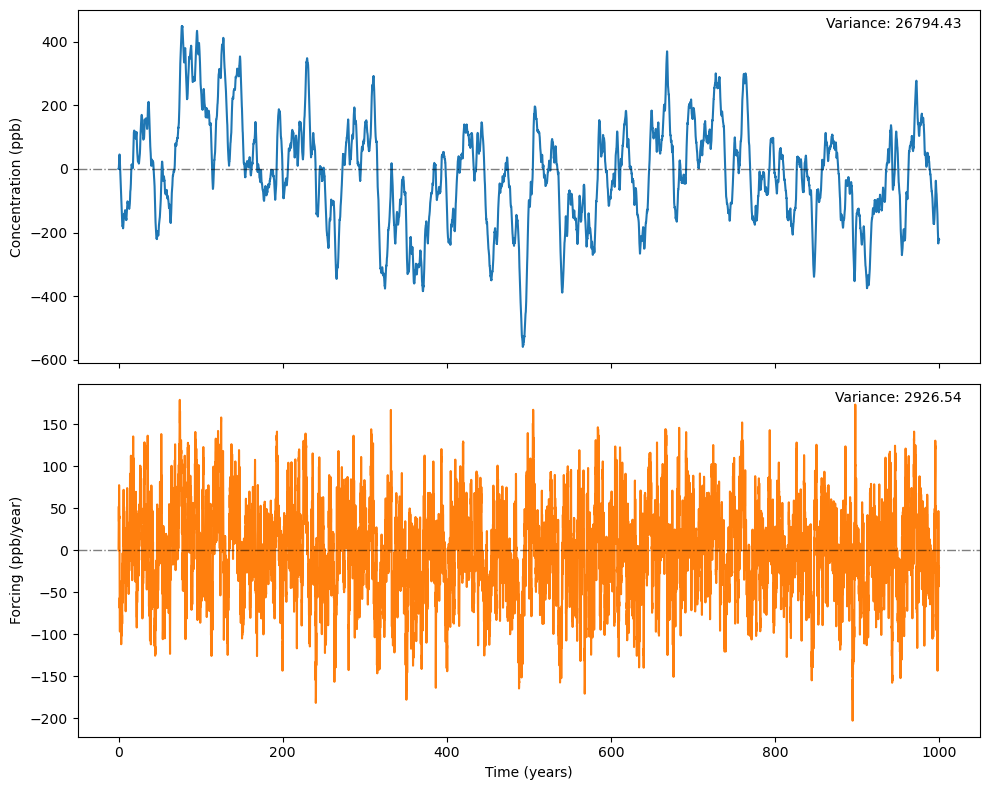

In [6]:
# visualize eta and x
idx_ens = 0

fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
time = np.arange(N) * dt

# Plot x
axs[0].plot(time, x_ens_naive[idx_ens, :], label="x (EM)", color="tab:blue")
axs[0].axhline(0, color="black", lw=1, ls="-.", alpha=0.5)
axs[0].set_ylabel("Concentration (ppb)")
# Calculate and annotate variance of x
var_x = np.var(x_ens_naive[idx_ens, :])
axs[0].text(
    0.98,
    0.98,
    f"Variance: {var_x:.2f}",
    ha="right",
    va="top",
    transform=axs[0].transAxes,
)

# Plot eta
axs[1].plot(time, eta_ens_naive[idx_ens, :], label="η (EM)", color="tab:orange")
axs[1].axhline(0, color="black", lw=1, ls="-.", alpha=0.5)
axs[1].set_ylabel("Forcing (ppb/year)")
axs[1].set_xlabel("Time (years)")
# Calculate and annotate variance of eta
var_eta = np.var(eta_ens_naive[idx_ens, :])
axs[1].text(
    0.98,
    0.98,
    f"Variance: {var_eta:.2f}",
    ha="right",
    va="top",
    transform=axs[1].transAxes,
)

plt.tight_layout()

# 2. Euler-Maruyama 2D

In [7]:
def simulate_em(tau_x, tau_eta, sigma_f, dt, N, n_ens, seed=42):
    np.random.seed(seed)
    A = np.array([[-1 / tau_x, 1], [0, -1 / tau_eta]])
    B = np.array([0, sigma_f])
    x_ens = np.zeros((n_ens, N))
    eta_ens = np.zeros((n_ens, N))
    for k in range(n_ens):
        state = np.zeros((2, N))
        for i in range(1, N):
            dW = np.sqrt(dt) * np.random.randn()
            state[:, i] = state[:, i - 1] + A @ state[:, i - 1] * dt + B * dW
        x_ens[k] = state[0]
        eta_ens[k] = state[1]
    return x_ens, eta_ens

In [8]:
# calculate the target variance
A_em = np.array([[-1 / tau_x, 1], [0, -1 / tau_eta]])
B_em = np.array([[0], [1]])  # unit σ
F_em = np.eye(2) + A_em * dt
Q_em_unit = B_em @ B_em.T * dt
Sigma_em = linalg.solve_discrete_lyapunov(F_em, Q_em_unit)
C3 = Sigma_em[0, 0]
sigma_em = np.sqrt(variance_x / C3)
var_eta_em = sigma_em**2 * Sigma_em[1, 1]

# simulate ensemble with EM
x_ens_em, eta_ens_em = simulate_em(tau_x, tau_eta, sigma_em, dt, N, n_ens)

print(f"EM variance of eta: {var_eta_em:.2f} (ppb/year)^2")
print(f"EM variance of forcing: {sigma_em**2:.2f} ppb^2/year^3")

EM variance of eta: 22.78 (ppb/year)^2
EM variance of forcing: 43.66 ppb^2/year^3


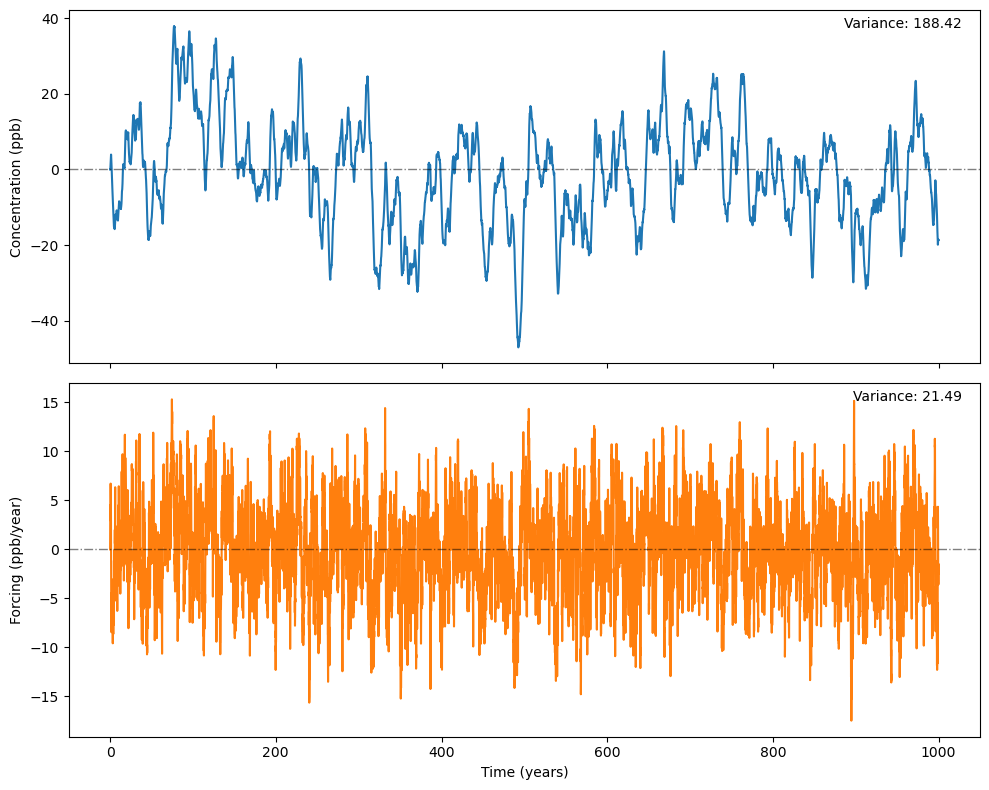

In [9]:
# visualize eta and x
idx_ens = 0

fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
time = np.arange(N) * dt

# Plot x
axs[0].plot(time, x_ens_em[idx_ens, :], label="x (EM)", color="tab:blue")
axs[0].axhline(0, color="black", lw=1, ls="-.", alpha=0.5)
axs[0].set_ylabel("Concentration (ppb)")
# Calculate and annotate variance of x
var_x = np.var(x_ens_em[idx_ens, :])
axs[0].text(
    0.98,
    0.98,
    f"Variance: {var_x:.2f}",
    ha="right",
    va="top",
    transform=axs[0].transAxes,
)

# Plot eta
axs[1].plot(time, eta_ens_em[idx_ens, :], label="η (EM)", color="tab:orange")
axs[1].axhline(0, color="black", lw=1, ls="-.", alpha=0.5)
axs[1].set_ylabel("Forcing (ppb/year)")
axs[1].set_xlabel("Time (years)")
# Calculate and annotate variance of eta
var_eta = np.var(eta_ens_em[idx_ens, :])
axs[1].text(
    0.98,
    0.98,
    f"Variance: {var_eta:.2f}",
    ha="right",
    va="top",
    transform=axs[1].transAxes,
)

plt.tight_layout()

## 3. Continuous-to-discrete simulation

In [10]:
def simulate_c2d(tau_x, tau_eta, sigma_f, dt, N, n_ens, seed=0):
    np.random.seed(seed)
    A = np.array([[-1 / tau_x, 1], [0, -1 / tau_eta]])
    B = np.array([[0], [1]])
    F = linalg.expm(A * dt)
    M = np.block([[A, B @ B.T], [np.zeros_like(A), -A.T]])
    expM = linalg.expm(M * dt)
    Q0 = expM[:2, 2:] @ linalg.inv(expM[2:, 2:])
    Q0 *= sigma_f**2
    L = np.linalg.cholesky(Q0)
    x_ens = np.zeros((n_ens, N))
    eta_ens = np.zeros((n_ens, N))
    for k in range(n_ens):
        state = np.zeros((2, N))
        for i in range(1, N):
            state[:, i] = F @ state[:, i - 1] + L @ np.random.randn(2)
        x_ens[k] = state[0]
        eta_ens[k] = state[1]
    return x_ens, eta_ens

In [11]:
A = np.array([[-1 / tau_x, 1], [0, -1 / tau_eta]])
B = np.array([[0], [1]])  # unit sigma
F6 = linalg.expm(A * dt)
M = np.block([[A, B @ B.T], [np.zeros_like(A), -A.T]])
expM = linalg.expm(M * dt)
Q0 = expM[:2, 2:] @ linalg.inv(expM[2:, 2:])
Sigma_c2d = linalg.solve_discrete_lyapunov(F6, Q0)
C6 = Sigma_c2d[0, 0]
sigma_c2d = np.sqrt(variance_x / C6)
var_eta_c2d = sigma_c2d**2 * Sigma_c2d[1, 1]

# simulate ensemble with C2D
x_ens_c2d, eta_ens_c2d = simulate_c2d(tau_x, tau_eta, sigma_c2d, dt, N, n_ens)

print(f"EM variance of eta: {var_eta_c2d:.2f} (ppb/year)^2")
print(f"EM variance of forcing: {sigma_c2d**2:.2f} ppb^2/year^3")

EM variance of eta: 22.00 (ppb/year)^2
EM variance of forcing: 44.00 ppb^2/year^3


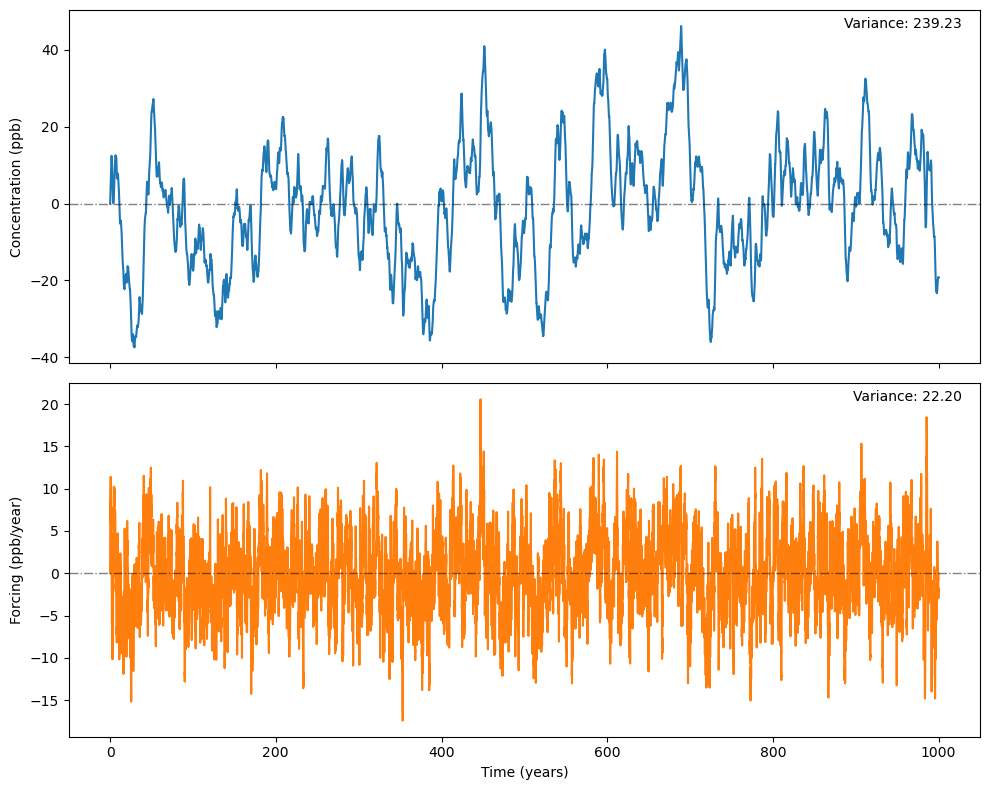

In [12]:
# visualize eta and x
idx_ens = 0

fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
time = np.arange(N) * dt

# Plot x
axs[0].plot(time, x_ens_c2d[idx_ens, :], label="x (EM)", color="tab:blue")
axs[0].axhline(0, color="black", lw=1, ls="-.", alpha=0.5)
axs[0].set_ylabel("Concentration (ppb)")
# Calculate and annotate variance of x
var_x = np.var(x_ens_c2d[idx_ens, :])
axs[0].text(
    0.98,
    0.98,
    f"Variance: {var_x:.2f}",
    ha="right",
    va="top",
    transform=axs[0].transAxes,
)

# Plot eta
axs[1].plot(time, eta_ens_c2d[idx_ens, :], label="η (EM)", color="tab:orange")
axs[1].axhline(0, color="black", lw=1, ls="-.", alpha=0.5)
axs[1].set_ylabel("Forcing (ppb/year)")
axs[1].set_xlabel("Time (years)")
# Calculate and annotate variance of eta
var_eta = np.var(eta_ens_c2d[idx_ens, :])
axs[1].text(
    0.98,
    0.98,
    f"Variance: {var_eta:.2f}",
    ha="right",
    va="top",
    transform=axs[1].transAxes,
)

plt.tight_layout()